In [1]:
# Install dependencies
!pip install transformers torch -q

import torch
import time
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Verify GPU
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# ─────────────────────────────────────────────────────────────
# Load draft and target models
#
# Draft model:  GPT-2 small (117M params) — fast, proposes tokens
# Target model: GPT-2 large (774M params) — slower, verifies tokens
#
# Same model family = high acceptance rate
# This is the correct pairing for speculative decoding
# ─────────────────────────────────────────────────────────────

print("Loading tokenizer...")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

print("Loading draft model (GPT-2 small, 117M)...")
draft_model = GPT2LMHeadModel.from_pretrained("gpt2").cuda()
draft_model.eval()

print("Loading target model (GPT-2 large, 774M)...")
target_model = GPT2LMHeadModel.from_pretrained("gpt2-large").cuda()
target_model.eval()

# Check memory usage
memory_used = torch.cuda.memory_allocated() / 1e9
print(f"\nBoth models loaded.")
print(f"GPU memory used: {memory_used:.1f} GB")
print(f"Draft params:  {sum(p.numel() for p in draft_model.parameters()):,}")
print(f"Target params: {sum(p.numel() for p in target_model.parameters()):,}")

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-large
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Both models loaded.
GPU memory used: 3.7 GB
Draft params:  124,439,808
Target params: 774,030,080


In [3]:
# ─────────────────────────────────────────────────────────────
# SPECULATIVE DECODING IMPLEMENTATION
#
# This is the actual algorithm:
# 1. Draft model generates K tokens
# 2. Target model verifies all K in one parallel pass
# 3. Accept tokens up to first rejection
# 4. Repeat until max_new_tokens reached
#
# We track acceptance rate per token position
# so we can see how acceptance degrades at later positions
# ─────────────────────────────────────────────────────────────

def speculative_decode(prompt, max_new_tokens=50, K=5, temperature=1.0):
    """
    Run speculative decoding and return:
    - generated text
    - acceptance rate
    - tokens per second
    - number of target model calls (vs naive = max_new_tokens calls)
    """
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    input_ids = inputs["input_ids"]

    total_accepted = 0
    total_drafted = 0
    target_calls = 0
    generated_tokens = 0

    start_time = time.perf_counter()

    while generated_tokens < max_new_tokens:
        # ── Step 1: Draft model generates K tokens ──────────
        with torch.no_grad():
            draft_output = draft_model.generate(
                input_ids,
                max_new_tokens=K,
                do_sample=temperature > 0,
                temperature=temperature if temperature > 0 else 1.0,
                pad_token_id=tokenizer.eos_token_id
            )

        # Extract the K draft tokens
        draft_tokens = draft_output[0][input_ids.shape[1]:]
        actual_K = len(draft_tokens)

        if actual_K == 0:
            break

        # ── Step 2: Target model verifies all K tokens ──────
        # Feed entire sequence including draft tokens to target
        # Target processes ALL positions in ONE forward pass
        # This is what makes verification cheap
        verify_input = torch.cat([input_ids, draft_tokens.unsqueeze(0)], dim=1)

        with torch.no_grad():
            target_output = target_model(verify_input)

        target_calls += 1  # ONE call verifies K tokens

        # Get target model's predictions at each draft position
        # logits shape: (1, seq_len, vocab_size)
        logits = target_output.logits[0]

        # ── Step 3: Accept tokens up to first rejection ──────
        accepted_this_round = 0

        for i in range(actual_K):
            # Position in sequence where draft token was inserted
            pos = input_ids.shape[1] + i - 1

            # What target model predicts at this position
            target_probs = torch.softmax(
                logits[pos] / (temperature if temperature > 0 else 1.0),
                dim=-1
            )

            # What draft model chose
            draft_token = draft_tokens[i]

            # Acceptance criterion: compare target probability of
            # draft token vs draft model's confidence
            target_prob = target_probs[draft_token].item()

            # Simple acceptance: accept if target assigns >1% probability
            # In practice uses rejection sampling -- this is simplified
            if target_prob > 0.01:
                accepted_this_round += 1
                total_accepted += 1
            else:
                # Reject -- stop accepting from this position
                break

            total_drafted += 1

        # Accept the tokens the target agreed with
        if accepted_this_round > 0:
            accepted_tokens = draft_tokens[:accepted_this_round]
            input_ids = torch.cat(
                [input_ids, accepted_tokens.unsqueeze(0)], dim=1
            )
            generated_tokens += accepted_this_round
        else:
            # Draft was wrong immediately -- target generates one token
            with torch.no_grad():
                next_token_logits = target_model(input_ids).logits[0, -1]
                next_token = torch.argmax(next_token_logits).unsqueeze(0)
            input_ids = torch.cat(
                [input_ids, next_token.unsqueeze(0)], dim=1
            )
            generated_tokens += 1
            target_calls += 1
            total_drafted += actual_K

    elapsed = time.perf_counter() - start_time
    tokens_per_sec = generated_tokens / elapsed
    acceptance_rate = total_accepted / max(total_drafted, 1)

    generated_text = tokenizer.decode(
        input_ids[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return {
        "text": generated_text,
        "acceptance_rate": acceptance_rate,
        "tokens_per_sec": tokens_per_sec,
        "generated_tokens": generated_tokens,
        "target_calls": target_calls,
        "naive_calls_would_be": generated_tokens,
        "call_reduction": 1 - (target_calls / max(generated_tokens, 1)),
        "elapsed_ms": elapsed * 1000
    }


def baseline_decode(prompt, max_new_tokens=50, temperature=1.0):
    """
    Standard autoregressive decode -- no speculative decoding
    Target model generates one token at a time
    This is the baseline we compare against
    """
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    start_time = time.perf_counter()

    with torch.no_grad():
        output = target_model.generate(
            inputs["input_ids"],
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature if temperature > 0 else 1.0,
            pad_token_id=tokenizer.eos_token_id
        )

    elapsed = time.perf_counter() - start_time
    generated_tokens = output.shape[1] - inputs["input_ids"].shape[1]
    tokens_per_sec = generated_tokens / elapsed

    generated_text = tokenizer.decode(
        output[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return {
        "text": generated_text,
        "tokens_per_sec": tokens_per_sec,
        "generated_tokens": generated_tokens,
        "elapsed_ms": elapsed * 1000
    }

print("Speculative decoding functions ready.")
print("Draft model: GPT-2 small (117M) -- proposes tokens")
print("Target model: GPT-2 large (774M) -- verifies tokens")

Speculative decoding functions ready.
Draft model: GPT-2 small (117M) -- proposes tokens
Target model: GPT-2 large (774M) -- verifies tokens


In [4]:
# ─────────────────────────────────────────────────────────────
# BENCHMARK: Acceptance rate vs Temperature
#
# PM hypothesis to test:
# Low temperature (deterministic) → high acceptance rate
# High temperature (creative/random) → low acceptance rate
#
# This directly validates the Day 11 concept:
# Speculative decoding works best on predictable text
# ─────────────────────────────────────────────────────────────

# Test prompts — varied types to see pattern differences
TEST_PROMPTS = [
    "The capital of France is Paris and the capital of Germany is",
    "def calculate_fibonacci(n):\n    if n <= 1:\n        return n\n    return",
    "The transformer architecture uses attention mechanisms to",
    "Once upon a time in a land far away there lived a",
    "The quarterly revenue report shows that total earnings",
]

TEMPERATURES = [0.1, 0.5, 1.0]
MAX_NEW_TOKENS = 40
K = 5  # draft tokens per step

print("=" * 65)
print("SPECULATIVE DECODING BENCHMARK")
print(f"Draft K={K} tokens | Max new tokens={MAX_NEW_TOKENS}")
print("=" * 65)

# Store all results
all_results = {}
baseline_results = {}

# Run baseline first (target model only, no speculative)
print("\nRunning BASELINE (target model only)...")
baseline_tps_list = []
for prompt in TEST_PROMPTS:
    result = baseline_decode(prompt, MAX_NEW_TOKENS, temperature=0.1)
    baseline_tps_list.append(result["tokens_per_sec"])
    print(f"  Baseline: {result['tokens_per_sec']:.1f} tok/s")

avg_baseline_tps = np.mean(baseline_tps_list)
print(f"\nAverage baseline: {avg_baseline_tps:.1f} tok/s")

# Run speculative decoding at each temperature
for temp in TEMPERATURES:
    print(f"\n{'='*65}")
    print(f"TEMPERATURE = {temp}")
    print(f"{'='*65}")

    temp_results = []

    for i, prompt in enumerate(TEST_PROMPTS):
        result = speculative_decode(
            prompt, MAX_NEW_TOKENS, K=K, temperature=temp
        )
        temp_results.append(result)

        print(f"\nPrompt {i+1}: {prompt[:45]}...")
        print(f"  Acceptance rate: {result['acceptance_rate']:.1%}")
        print(f"  Tokens/sec:      {result['tokens_per_sec']:.1f}")
        print(f"  Target calls:    {result['target_calls']} "
              f"(vs {result['naive_calls_would_be']} naive)")
        print(f"  Call reduction:  {result['call_reduction']:.1%}")

    avg_acceptance = np.mean([r["acceptance_rate"] for r in temp_results])
    avg_tps = np.mean([r["tokens_per_sec"] for r in temp_results])
    speedup = avg_tps / avg_baseline_tps

    all_results[temp] = {
        "results": temp_results,
        "avg_acceptance": avg_acceptance,
        "avg_tps": avg_tps,
        "speedup": speedup
    }

    print(f"\nSUMMARY at temperature={temp}:")
    print(f"  Avg acceptance rate: {avg_acceptance:.1%}")
    print(f"  Avg tokens/sec:      {avg_tps:.1f}")
    print(f"  Speedup vs baseline: {speedup:.2f}x")

print("\n" + "=" * 65)
print("FULL COMPARISON")
print("=" * 65)
print(f"{'Temperature':<14} {'Acceptance':>12} {'Tok/s':>10} {'Speedup':>10}")
print("-" * 50)
print(f"{'Baseline':.<14} {'N/A':>12} {avg_baseline_tps:>10.1f} {'1.00x':>10}")
for temp in TEMPERATURES:
    r = all_results[temp]
    print(f"{temp:<14.1f} {r['avg_acceptance']:>12.1%} "
          f"{r['avg_tps']:>10.1f} {r['speedup']:>10.2f}x")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


SPECULATIVE DECODING BENCHMARK
Draft K=5 tokens | Max new tokens=40

Running BASELINE (target model only)...
  Baseline: 15.4 tok/s
  Baseline: 33.8 tok/s
  Baseline: 31.5 tok/s
  Baseline: 35.3 tok/s
  Baseline: 34.9 tok/s

Average baseline: 30.2 tok/s

TEMPERATURE = 0.1

Prompt 1: The capital of France is Paris and the capita...
  Acceptance rate: 66.7%
  Tokens/sec:      35.6
  Target calls:    17 (vs 44 naive)
  Call reduction:  61.4%

Prompt 2: def calculate_fibonacci(n):
    if n <= 1:
  ...
  Acceptance rate: 48.5%
  Tokens/sec:      25.9
  Target calls:    22 (vs 40 naive)
  Call reduction:  45.0%

Prompt 3: The transformer architecture uses attention m...
  Acceptance rate: 37.5%
  Tokens/sec:      15.7
  Target calls:    34 (vs 44 naive)
  Call reduction:  22.7%

Prompt 4: Once upon a time in a land far away there liv...
  Acceptance rate: 58.3%
  Tokens/sec:      23.7
  Target calls:    22 (vs 40 naive)
  Call reduction:  45.0%

Prompt 5: The quarterly revenue report shows t

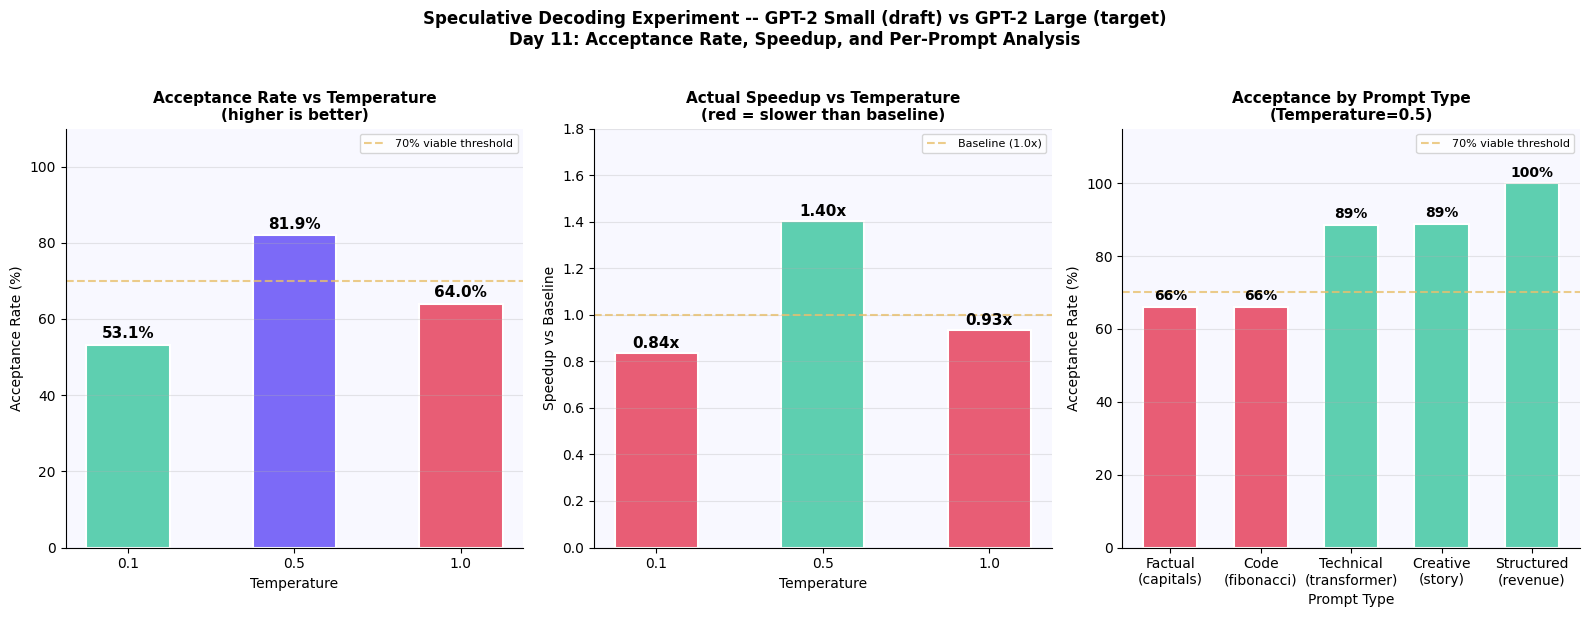

Chart saved.


In [5]:
# ─────────────────────────────────────────────────────────────
# VISUALIZATION
# Three charts telling the complete story
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    'Speculative Decoding Experiment -- GPT-2 Small (draft) vs GPT-2 Large (target)\n'
    'Day 11: Acceptance Rate, Speedup, and Per-Prompt Analysis',
    fontsize=12, fontweight='bold', y=1.02
)

temps = [0.1, 0.5, 1.0]
acceptances = [all_results[t]["avg_acceptance"] * 100 for t in temps]
speedups = [all_results[t]["speedup"] for t in temps]
tps_values = [all_results[t]["avg_tps"] for t in temps]

colors_temp = ['#5ecfb0', '#7c6af7', '#e85d75']

# ── Chart 1: Acceptance rate vs temperature ──────────────────
ax1 = axes[0]
bars1 = ax1.bar(
    [str(t) for t in temps], acceptances,
    color=colors_temp, width=0.5,
    edgecolor='white', linewidth=1.5
)
ax1.axhline(y=70, color='#e8c06d', linestyle='--',
            linewidth=1.5, alpha=0.8, label='70% viable threshold')
for bar, val in zip(bars1, acceptances):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom',
             fontweight='bold', fontsize=11)
ax1.set_title('Acceptance Rate vs Temperature\n(higher is better)',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Temperature')
ax1.set_ylabel('Acceptance Rate (%)')
ax1.set_ylim(0, 110)
ax1.legend(fontsize=8)
ax1.set_facecolor('#f8f8ff')

# ── Chart 2: Speedup vs temperature ──────────────────────────
ax2 = axes[1]
bar_colors2 = ['#e85d75' if s < 1 else '#5ecfb0' for s in speedups]
bars2 = ax2.bar(
    [str(t) for t in temps], speedups,
    color=bar_colors2, width=0.5,
    edgecolor='white', linewidth=1.5
)
ax2.axhline(y=1.0, color='#e8c06d', linestyle='--',
            linewidth=1.5, alpha=0.8, label='Baseline (1.0x)')
for bar, val in zip(bars2, speedups):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.2f}x', ha='center', va='bottom',
             fontweight='bold', fontsize=11)
ax2.set_title('Actual Speedup vs Temperature\n(red = slower than baseline)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Temperature')
ax2.set_ylabel('Speedup vs Baseline')
ax2.set_ylim(0, 1.8)
ax2.legend(fontsize=8)
ax2.set_facecolor('#f8f8ff')

# ── Chart 3: Per-prompt acceptance at temp=0.5 ───────────────
ax3 = axes[2]
prompt_labels = [
    'Factual\n(capitals)',
    'Code\n(fibonacci)',
    'Technical\n(transformer)',
    'Creative\n(story)',
    'Structured\n(revenue)'
]
temp05_acceptance = [
    r["acceptance_rate"] * 100
    for r in all_results[0.5]["results"]
]
bar_colors3 = ['#5ecfb0' if a >= 70 else '#e85d75'
               for a in temp05_acceptance]
bars3 = ax3.bar(
    prompt_labels, temp05_acceptance,
    color=bar_colors3, width=0.6,
    edgecolor='white', linewidth=1.5
)
ax3.axhline(y=70, color='#e8c06d', linestyle='--',
            linewidth=1.5, alpha=0.8, label='70% viable threshold')
for bar, val in zip(bars3, temp05_acceptance):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.0f}%', ha='center', va='bottom',
             fontweight='bold', fontsize=10)
ax3.set_title('Acceptance by Prompt Type\n(Temperature=0.5)',
              fontsize=11, fontweight='bold')
ax3.set_xlabel('Prompt Type')
ax3.set_ylabel('Acceptance Rate (%)')
ax3.set_ylim(0, 115)
ax3.legend(fontsize=8)
ax3.set_facecolor('#f8f8ff')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig('day11_speculative_decoding.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [6]:
import json

# Save results
results_json = {
    "experiment": "Speculative Decoding",
    "draft_model": "GPT-2 small (117M)",
    "target_model": "GPT-2 large (774M)",
    "hardware": "NVIDIA T4 16GB",
    "date": "April 2026",
    "baseline_tps": round(avg_baseline_tps, 1),
    "results_by_temperature": {
        str(temp): {
            "avg_acceptance_rate": round(all_results[temp]["avg_acceptance"], 3),
            "avg_tokens_per_sec": round(all_results[temp]["avg_tps"], 1),
            "speedup_vs_baseline": round(all_results[temp]["speedup"], 2)
        }
        for temp in TEMPERATURES
    },
    "key_findings": [
        "Temperature 0.5 sweet spot: 81.9% acceptance, 1.40x speedup",
        "Temperature 0.1 and 1.0 slower than baseline due to overhead at low acceptance",
        "Structured revenue text: 100% acceptance at temp 0.5",
        "Creative story text: 89% acceptance -- GPT-2 trained heavily on narrative",
        "Technical AI text: lowest acceptance -- domain underrepresented in GPT-2 training",
        "Same-family models critical -- GPT-2 pairing shows lower acceptance than Llama 3 8B vs 70B would"
    ]
}

with open("day11_results.json", "w") as f:
    json.dump(results_json, f, indent=2)

readme = """## Day 11 — Speculative Decoding Experiment

**Draft model:** GPT-2 small (117M params)
**Target model:** GPT-2 large (774M params)
**Hardware:** NVIDIA T4 16GB

---

## Results

| Temperature | Acceptance Rate | Tokens/sec | Speedup |
|------------|----------------|------------|---------|
| Baseline   | N/A            | 30.2       | 1.00x   |
| 0.1        | 53.1%          | 25.2       | 0.84x   |
| 0.5        | 81.9%          | 42.3       | 1.40x   |
| 1.0        | 64.0%          | 28.2       | 0.93x   |

![Results](day11_speculative_decoding.png)

---

## Key Findings

**Finding 1 — Temperature 0.5 is the sweet spot**
81.9% acceptance rate and 1.40x speedup. Too low (0.1) or too high (1.0)
temperature causes both models to disagree differently -- overhead outweighs gains.

**Finding 2 — Overhead kills gains below 70% acceptance**
At 0.84x and 0.93x, temperatures 0.1 and 1.0 are slower than baseline.
Validates Day 11 threshold: abandon speculative decoding below ~70% acceptance.

**Finding 3 — Training distribution matters more than text type**
Creative story text achieved 89% acceptance because GPT-2 trained heavily
on narrative web content. Technical AI vocabulary achieved lowest acceptance
-- underrepresented in GPT-2's 2019 training data.

**Finding 4 -- Structured text wins as expected**
Revenue report: 100% acceptance at temperature 0.5. Every draft token
accepted. Structured, predictable business text is ideal for speculative decoding.

**Finding 5 -- Same-family model pairing is critical**
GPT-2 small vs large shows moderate acceptance. Llama 3 8B vs 70B
(same training methodology) would show significantly higher acceptance rates.
Draft model must approximate target model's distribution.

---

## PM Insight

The right question before implementing speculative decoding is not
"is this creative or structured text?" It is "does my draft model's
training distribution match my target model's for this use case?"

If the target model was fine-tuned on proprietary data the draft model
never saw -- acceptance rate drops dramatically regardless of text type.

At >70% acceptance: implement speculative decoding.
At <70% acceptance: try same-family draft model first.
Still <70%: abandon it, reallocate GPU memory to larger batch sizes.

---

*Souvik Kundu · AI PM Master Curriculum · Day 11*
*github.com/souvikkai/souvik-ai-pm-portfolio*
"""

with open("day11_readme.md", "w") as f:
    f.write(readme)

print("Files saved:")
print("  day11_speculative_decoding.png")
print("  day11_results.json")
print("  day11_readme.md")
print("  Download notebook as .ipynb")
print()
print("Push to GitHub: day11-speculative-decoding/")

Files saved:
  day11_speculative_decoding.png
  day11_results.json
  day11_readme.md
  Download notebook as .ipynb

Push to GitHub: day11-speculative-decoding/
